In [37]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from numpy.ma.core import shape


In [38]:
df = pd.read_csv('churn.csv')
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [39]:
df.shape

(3150, 14)

In [40]:
df.Churn.value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

<Axes: xlabel='Churn'>

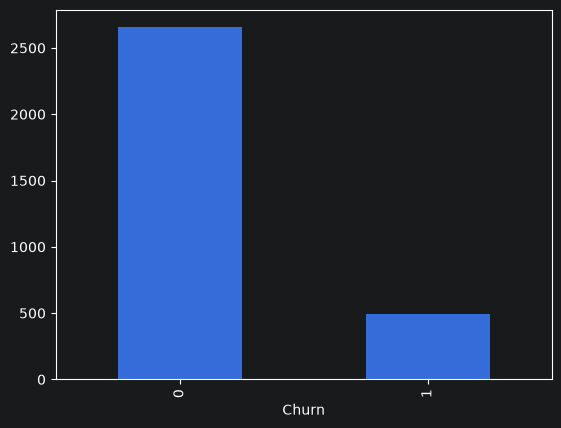

In [41]:
df.Churn.value_counts().plot(kind='bar')

In [42]:
df.isna().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [43]:
X = df.drop("Churn", axis='columns')
y = df["Churn"]

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression(max_iter=10000)  # Increase max_iter if convergence issues occur
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       531
           1       0.78      0.40      0.53        99

    accuracy                           0.89       630
   macro avg       0.84      0.69      0.74       630
weighted avg       0.88      0.89      0.87       630



In [53]:
y_train.value_counts()

Churn
0    2124
1     396
Name: count, dtype: int64

In [54]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

y_train_rus.value_counts()



Churn
0    396
1    396
Name: count, dtype: int64

In [55]:
model = LogisticRegression(max_iter=20000)
model.fit(X_train_rus, y_train_rus)

y_pred_rus = model.predict(X_test)
report = classification_report(y_test, y_pred_rus)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.81      0.88       531
           1       0.46      0.85      0.60        99

    accuracy                           0.82       630
   macro avg       0.71      0.83      0.74       630
weighted avg       0.89      0.82      0.84       630



In [56]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()

Churn
0    2124
1    2124
Name: count, dtype: int64

In [57]:
model = LogisticRegression(max_iter=20000)
model.fit(X_train_smote, y_train_smote)

y_pred_smote = model.predict(X_test)
report = classification_report(y_test, y_pred_smote)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.80      0.88       531
           1       0.44      0.85      0.58        99

    accuracy                           0.81       630
   macro avg       0.71      0.83      0.73       630
weighted avg       0.88      0.81      0.83       630



In [58]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_tomek, y_tomek = smt.fit_resample(X_train, y_train)
y_tomek.value_counts()

Churn
0    2091
1    2091
Name: count, dtype: int64

In [59]:
model = LogisticRegression(max_iter=20000)
model.fit(X_tomek, y_tomek)

y_pred_tomek = model.predict(X_test)
report = classification_report(y_test, y_pred_tomek)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.80      0.88       531
           1       0.45      0.86      0.59        99

    accuracy                           0.81       630
   macro avg       0.71      0.83      0.73       630
weighted avg       0.89      0.81      0.83       630

